# Exercise 02 — Guide: AlphaFold prediction and confidence

## Learning Objectives

Take a real, extensively studied protein, pull **AlphaFold's actual prediction for it from
the public API**, and work out how much of it to believe. You will:

- fetch a prediction and **know exactly where every number came from**
- read **pLDDT** — and see why the mean hides more than it reveals
- read **PAE**, which answers a question pLDDT cannot
- read **AlphaMissense**, a metric about *function* rather than geometry
- compare the prediction against a **crystal structure** and measure the difference
- find what the model leaves out entirely

**No GPU required.** Everything here is HTTP calls and plotting — it runs on a plain CPU
runtime in about a minute.

## About AI and This Exercise

**What AI CAN help with:** understanding AlphaFold's metrics, syntax, and general
protein-folding principles.

**What YOU must demonstrate:** hypothesis formulation (predictions before running
anything), critical evaluation of what the numbers actually support, and biological
reasoning connecting sequence to structure to function.

**Exercise 02 is two notebooks:**

| Notebook | What it is |
|---|---|
| **`ex02_guide.ipynb`** (this one) | The full worked analysis on human p53 / PDB **3D08**. Every cell is filled in and explained. Nothing here is graded. |
| **`ex02_workbook.ipynb`** | The graded notebook. Open it once you have finished here. |

# Alphafold

[AlphaFold](https://deepmind.google/technologies/alphafold/), an AI system developed by DeepMind, has solved the complex protein-folding problem, allowing for almost instant and highly accurate predictions of protein structures, which are crucial for understanding cellular functions and advancing medical research. Recognized by the [Critical Assessment of protein Structure Prediction community](https://www.predictioncenter.org/), AlphaFold has [significantly](https://www.predictioncenter.org/casp14/zscores_final.cgi) expanded the availability of protein structure data through the freely accessible AlphaFold Protein Structure Database.

---

## The protein: p53 and the 3D08 crystal

We take a real, extensively studied protein, pull **AlphaFold's actual prediction for it from the public API**, and
work out how much of it to believe.

The protein is the **core (DNA-binding) domain of human p53** — "the guardian of the
genome", the most commonly mutated gene in human cancer. PDB entry **3D08** carries a real
cancer-hotspot mutation, **R249S**, and coordinates a structural Zn²⁺ ion required for the
domain to fold.

We will not re-run AlphaFold here. The **AlphaFold Protein Structure Database** already
holds a prediction for every UniProt sequence, and exposes it through a REST API — so we
can fetch the model, its per-residue confidence, and its PAE matrix directly, then plot and
interrogate all three.

**How you'd reason about this before running anything (a worked example of
predict-first):** p53 (UniProt `P04637`) is 393 residues, but 3D08's crystal resolved only
residues 97-287 — the rest was never modelled. Before fetching a single number, the
biologically motivated prediction is: confidence will be **split**, not uniform, and the
*confident* part will be the crystallised core domain. A domain that crystallises cleanly
has a single well-defined fold, which is exactly what a predictor has abundant evidence
for. The regions a crystal never resolved are the suspicious ones.

**This is the same evidence you already know how to gather.** In ex01 you read two
crystallographic signals off a structure: which residues the crystal **failed to resolve**,
and which resolved residues carry the **highest B-factors**. Both say the same thing — that
region is mobile — and both are the natural input to a guess about where a predictor will
be least confident. Watch what the real numbers do with that prediction.

In [1]:
# Setup. Everything in this notebook runs on a plain CPU runtime.
try:
    from google.colab import drive

    is_google_colab = True
except ImportError:
    is_google_colab = False

if is_google_colab:
    %pip install numpy==2.1.3 pandas==2.2.3 matplotlib==3.10.0 py3dmol==2.4.0

import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import py3Dmol
import requests

print("Libraries loaded -- no GPU needed")

Libraries loaded -- no GPU needed


## Where this data comes from

Before plotting anything, it is worth being precise about **what we are downloading and
from where** — partly so you can repeat it for your own protein, and partly because
"the model says 95" means nothing if you cannot say which model, which version, and which
file the number came from.

Everything below comes from the **AlphaFold Protein Structure Database**, and the whole
chain starts from a single UniProt accession:

```
UniProt accession  ->  https://alphafold.ebi.ac.uk/api/prediction/{accession}
                            |
                            +-- globalMetricValue      the headline mean pLDDT
                            +-- fractionPlddt*         how much sits in each confidence band
                            +-- pdbUrl        -------> the predicted structure  (.pdb)
                            +-- cifUrl        -------> the same, as mmCIF
                            +-- plddtDocUrl   -------> per-residue confidence   (.json)
                            +-- paeDocUrl     -------> predicted aligned error  (.json)
                            +-- msaUrl        -------> the alignment used       (.a3m)
```

One call returns a small JSON record that **contains the URLs of everything else**. You
never construct those URLs yourself — you read them out of the record, which is why this
keeps working when AlphaFold DB bumps its version suffix (`_v4`, `_v6`, …).

For p53 the accession is **`P04637`**. Note what that means: AlphaFold DB is keyed by
**UniProt sequence, not by PDB entry**. There is no prediction "for 3D08". There is a
prediction for the canonical human p53 sequence, which we then compare against the 3D08
crystal. That distinction matters — 3D08 is the R249S mutant, and the AlphaFold model is
wild-type.

The cell below fetches everything once, saves it next to the notebook, and prints exactly
what each file contains.

In [2]:
import json
from pathlib import Path

UNIPROT = "P04637"          # human p53
DATA = Path("afdb_data")
DATA.mkdir(exist_ok=True)

# --- 1. the one call that gives you everything else -------------------------
api_url = f"https://alphafold.ebi.ac.uk/api/prediction/{UNIPROT}"
entries = requests.get(api_url).json()
entry = next(e for e in entries if e["modelEntityId"] == f"AF-{UNIPROT}-F1")
(DATA / f"afdb_{UNIPROT}.json").write_text(json.dumps(entry, indent=2))

print(f"GET {api_url}")
print(f"  -> {len(entries)} entry/entries; using {entry['modelEntityId']}\n")
print("  fields we will actually use:")
for key in ("modelEntityId", "uniprotSequence", "globalMetricValue", "modelCreatedDate",
            "latestVersion", "pdbUrl", "plddtDocUrl", "paeDocUrl", "msaUrl"):
    if key in entry:
        value = entry[key]
        shown = f"{value[:52]}..." if isinstance(value, str) and len(value) > 55 else value
        print(f"    {key:<20} {shown}")

# --- 2. follow each URL the record handed us --------------------------------
downloads = {
    "model.pdb":        entry["pdbUrl"],
    "confidence.json":  entry["plddtDocUrl"],
    "pae.json":         entry["paeDocUrl"],
}
print("\n  downloading:")
for name, url in downloads.items():
    response = requests.get(url)
    target = DATA / f"AF-{UNIPROT}-F1-{name}"
    if response.status_code != 200:
        print(f"    {name:<18} HTTP {response.status_code}  <-- unavailable, skipped")
        continue
    target.write_bytes(response.content)
    print(f"    {name:<18} {len(response.content):>9,} bytes  -> {target}")

# msaUrl is listed above but has been returning HTTP 403 since 2026-08; we do not rely on it.
msa_status = requests.get(entry["msaUrl"]).status_code
print(f"    {'msa.a3m':<18} HTTP {msa_status}" + ("  <-- not public; alignment work lives in ex01"
                                                  if msa_status != 200 else ""))

GET https://alphafold.ebi.ac.uk/api/prediction/P04637
  -> 9 entry/entries; using AF-P04637-F1

  fields we will actually use:
    modelEntityId        AF-P04637-F1
    uniprotSequence      MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLSPDDIEQ...
    globalMetricValue    75.06
    modelCreatedDate     2025-08-01T00:00:00Z
    latestVersion        6
    pdbUrl               https://alphafold.ebi.ac.uk/files/AF-P04637-F1-model...
    plddtDocUrl          https://alphafold.ebi.ac.uk/files/AF-P04637-F1-confi...
    paeDocUrl            https://alphafold.ebi.ac.uk/files/AF-P04637-F1-predi...
    msaUrl               https://alphafold.ebi.ac.uk/files/msa/AF-P04637-F1-m...

  downloading:
    model.pdb            254,339 bytes  -> afdb_data/AF-P04637-F1-model.pdb
    confidence.json        5,417 bytes  -> afdb_data/AF-P04637-F1-confidence.json
    pae.json             422,267 bytes  -> afdb_data/AF-P04637-F1-pae.json
    msa.a3m            HTTP 403  <-- not public; alignment work lives in ex01

### What each file looks like

Knowing the *shape* of these files is what lets you use them. Run the next cell and read
the output alongside this table:

| File | Structure |
|---|---|
| `afdb_P04637.json` | one flat record — summary metrics plus the URLs above |
| `...confidence.json` | three parallel lists: `residueNumber`, `confidenceScore`, `confidenceCategory` |
| `...pae.json` | a list with one object holding `predicted_aligned_error` (an *n × n* matrix) and `max_predicted_aligned_error` |
| `...model.pdb` | a normal PDB file — **with pLDDT written into the B-factor column** |

That last one is the detail people miss. AlphaFold does not ship a separate confidence
file for the structure; it **reuses the B-factor column**. So any tool that colours a
structure by B-factor — PyMOL, ChimeraX, py3Dmol — colours an AlphaFold model by
confidence for free. It also means you must **never** read those numbers as real
crystallographic B-factors. Same column, completely different meaning.

In [3]:
# Read each file back from disk and show its actual shape.
conf = json.loads((DATA / f"AF-{UNIPROT}-F1-confidence.json").read_text())
print("confidence.json")
print(f"  keys        : {list(conf.keys())}")
print(f"  n residues  : {len(conf['residueNumber'])}")
print(f"  first 5     : residue {conf['residueNumber'][:5]}")
print(f"                score   {conf['confidenceScore'][:5]}")
print(f"                category{conf['confidenceCategory'][:5]}   (D/L/M/H = disordered->high)")

pae_raw = json.loads((DATA / f"AF-{UNIPROT}-F1-pae.json").read_text())
pae_obj = pae_raw[0]
print(f"\npae.json")
print(f"  keys        : {list(pae_obj.keys())}")
matrix = np.array(pae_obj["predicted_aligned_error"])
print(f"  matrix      : {matrix.shape}  dtype {matrix.dtype}")
print(f"  value range : {matrix.min():.1f} to {matrix.max():.1f} A (max_predicted_aligned_error"
      f" = {pae_obj['max_predicted_aligned_error']})")

model_lines = (DATA / f"AF-{UNIPROT}-F1-model.pdb").read_text().splitlines()
atom_lines = [l for l in model_lines if l.startswith("ATOM")]
print(f"\nmodel.pdb")
print(f"  ATOM records: {len(atom_lines):,}")
print(f"  first ATOM  : {atom_lines[0][:66]}")
print(f"                                                     ^^^^^^ B-factor column = pLDDT")

# Prove the B-factor column really is the pLDDT from confidence.json
first_ca = next(l for l in atom_lines if l[12:16].strip() == "CA")
print(f"\n  residue 1 pLDDT from confidence.json : {conf['confidenceScore'][0]}")
print(f"  residue 1 B-factor from model.pdb    : {float(first_ca[60:66])}")

confidence.json
  keys        : ['residueNumber', 'confidenceScore', 'confidenceCategory']
  n residues  : 393
  first 5     : residue [1, 2, 3, 4, 5]
                score   [42.72, 43.59, 37.78, 45.91, 39.31]
                category['D', 'D', 'D', 'D', 'D']   (D/L/M/H = disordered->high)

pae.json
  keys        : ['predicted_aligned_error', 'max_predicted_aligned_error']
  matrix      : (393, 393)  dtype int64
  value range : 0.0 to 32.0 A (max_predicted_aligned_error = 31.75)

model.pdb
  ATOM records: 3,060
  first ATOM  : ATOM      1  N   MET A   1      63.063 -13.528  -5.589  1.00 42.72
                                                     ^^^^^^ B-factor column = pLDDT

  residue 1 pLDDT from confidence.json : 42.72
  residue 1 B-factor from model.pdb    : 42.72


In [4]:
# Query the AlphaFold DB REST API for the real, full-length human p53 prediction.
# A lightweight HTTP call: no GPU, no model weights, nothing to install.
UNIPROT = "P04637"          # human p53

# json_normalize flattens the response straight into a DataFrame -- one row per model.
entries = pd.json_normalize(
    requests.get(f"https://alphafold.ebi.ac.uk/api/prediction/{UNIPROT}").json()
)
# The API can return more than one fragment for very long proteins; p53 fits in one.
entry = entries.set_index("modelEntityId").loc[f"AF-{UNIPROT}-F1"]

print(f"Model: {entry.name}  (pipeline: {entry['toolUsed']})")
print(f"Sequence length: {entry['sequenceEnd'] - entry['sequenceStart'] + 1} residues")
print(f"Global mean pLDDT: {entry['globalMetricValue']:.1f}\n")

# The four confidence-band fractions are just columns -- select them by prefix.
bands = entry.filter(like="fractionPlddt").rename(
    lambda c: c.replace("fractionPlddt", "")
)
print("Confidence-bin fractions (AlphaFold DB's own bins):")
print((bands * 100).round(1).to_string())

Model: AF-P04637-F1  (pipeline: AlphaFold Monomer v2.0 pipeline)
Sequence length: 393 residues
Global mean pLDDT: 75.1
Confidence-bin fractions (AlphaFold DB's own bins):
  Very low (pLDDT < 50):  29.8%
  Low      (50-70):       10.4%
  Confident(70-90):       7.1%
  Very high(>90):         52.7%


Before interpreting that number, let's zoom in on exactly the region 3D08's crystal
actually covers (residues 97-287) — not the whole 393-residue protein.


In [5]:
# Per-residue confidence. `pd.read_json` reads the URL directly -- no requests call,
# no hand-built dict. The file is three parallel arrays, which is already a table.
confidence = (
    pd.read_json(entry["plddtDocUrl"])
    .rename(columns={"confidenceScore": "pLDDT", "confidenceCategory": "category"})
    .set_index("residueNumber")
)

CRYSTAL_START, CRYSTAL_END = 97, 287        # 3D08's own resolved range

# Indexing by residue number means slicing a range reads like the biology.
core = confidence.loc[CRYSTAL_START:CRYSTAL_END, "pLDDT"]

print(f"AlphaFold mean pLDDT over 3D08's resolved range "
      f"({CRYSTAL_START}-{CRYSTAL_END}): {core.mean():.1f}")
print(f"Fraction of that range with pLDDT < 70: {(core < 70).mean()*100:.1f}%")

print("\npLDDT right around the R249S hotspot position (240-260):")
print(confidence.loc[240:260].to_string())

AlphaFold mean pLDDT over 3D08's resolved range (97-287): 95.6
Fraction of that range with pLDDT < 70: 1.0%

pLDDT right around the R249S hotspot position (240-260):
 residueNumber  pLDDT
           240  98.25
           241  97.81
           242  97.44
           243  96.62
           244  93.75
           245  94.81
           246  97.12
           247  97.50
           248  97.25
           249  97.81
           250  98.06
           251  98.56
           252  98.44
           253  98.62
           254  98.62
           255  98.69
           256  98.69
           257  98.56
           258  98.50
           259  97.44
           260  96.38


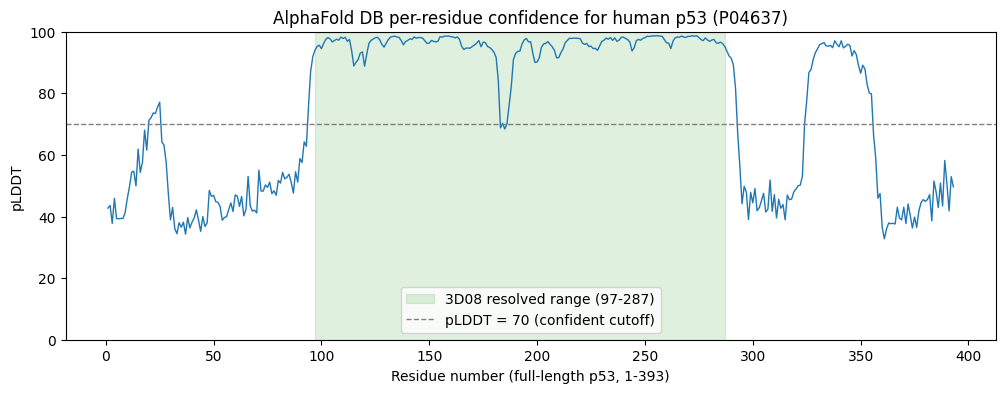

In [6]:
# Plot straight off the DataFrame: the index is already the residue number, so pandas
# labels the x-axis for us and we only add the annotations that carry meaning.
ax = confidence["pLDDT"].plot(
    figsize=(12, 4), color="tab:blue", lw=1,
    title=f"AlphaFold DB per-residue confidence for human p53 ({UNIPROT})",
)
ax.axvspan(CRYSTAL_START, CRYSTAL_END, color="tab:green", alpha=0.15,
           label=f"3D08 resolved range ({CRYSTAL_START}-{CRYSTAL_END})")
ax.axhline(70, color="grey", ls="--", lw=1, label="pLDDT = 70 (confident cutoff)")
ax.set_xlabel("Residue number (full-length p53, 1-393)")
ax.set_ylabel("pLDDT")
ax.set_ylim(0, 100)
ax.legend(loc="lower center")
plt.show()

### Predicted Aligned Error (PAE)

pLDDT tells you how confident AlphaFold is about *where a residue sits locally*. It does
not tell you how confident AlphaFold is about the **relative position of two residues
that are far apart in sequence** — two domains can each individually have high pLDDT
while AlphaFold is still unsure how they're oriented relative to each other. That's what
**PAE** (Predicted Aligned Error) is for: a full residue-by-residue matrix, where a low
value at (i, j) means AlphaFold is confident about residue j's position *if you fix
residue i in place*. AlphaFold DB publishes the full PAE matrix for every entry, the
same way it publishes pLDDT.

PAE matrix shape: 393 x 393 residues
Max PAE in this entry: 31.8 Å


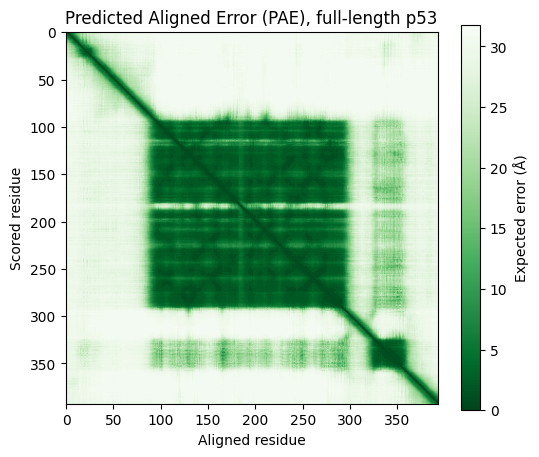

In [7]:
# The PAE file is one record holding an n x n matrix. read_json gives us that record;
# wrapping the matrix in a DataFrame makes it slice-able by residue number too.
pae_record = pd.read_json(entry["paeDocUrl"]).iloc[0]
pae = pd.DataFrame(pae_record["predicted_aligned_error"])
pae.index += 1                      # residue numbering starts at 1, not 0
pae.columns += 1

print(f"PAE matrix: {pae.shape[0]} x {pae.shape[1]} residues")
print(f"Max PAE in this entry: {pae_record['max_predicted_aligned_error']:.1f} A")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(pae, cmap="Greens_r", vmin=0, vmax=pae.values.max(),
               extent=[1, pae.shape[1], pae.shape[0], 1])
ax.set_xlabel("Aligned residue"); ax.set_ylabel("Scored residue")
ax.set_title("Predicted Aligned Error (PAE), full-length p53")
fig.colorbar(im, ax=ax, label="Expected error (A)")
plt.show()

# Because it is a DataFrame, questions about regions are now one line each:
core_block = pae.loc[CRYSTAL_START:CRYSTAL_END, CRYSTAL_START:CRYSTAL_END]
print(f"\nMean PAE within the core domain  : {core_block.values.mean():.1f} A")
print(f"Mean PAE core vs. N-terminal tail : "
      f"{pae.loc[CRYSTAL_START:CRYSTAL_END, 1:CRYSTAL_START-1].values.mean():.1f} A")

**What just happened:** the *global* average for full-length p53 (~75, with ~40% of
the sequence in AlphaFold DB's low/very-low confidence bins) looks like a real weak
spot. But restricted to exactly the domain 3D08 crystallized (97-287), AlphaFold is
actually **very** confident (mean pLDDT ≈ 95-96, only ~1% below 70) — including right at
the R249 mutation hotspot itself. The pLDDT plot above shows this directly: a sharp,
visible step at the boundaries of the shaded region, not a gradual decline.

The low-confidence 40% comes almost entirely from p53's N- and C-terminal regulatory
regions, which are **intrinsically disordered** — they genuinely have no single fixed
shape in solution. AlphaFold being unconfident there isn't a prediction failure; it's the
correct answer for a region that doesn't fold into one structure.

This is exactly the kind of thing to check before trusting (or dismissing) an AlphaFold
confidence score: a single overall number can hide very different stories in different
parts of the same protein. You now have two independent views of that story — pLDDT and
PAE — rather than one summary statistic.

*(A third view, the depth of the MSA AlphaFold used, is a natural next question. Building
and reading an alignment is exactly what you did in ex01, so that is where the
conservation work lives in this course.)*

---

## Beyond pLDDT: the other metrics AlphaFold DB gives you

pLDDT and PAE are the two everyone quotes, and they answer the same *kind* of question —
**how sure is the model about where things are?** The prediction record carries more than
that, and one of the extras answers a completely different question: **does changing this
residue break the protein?**

### The confidence composition

Before the new metric, one small thing already in the record. Alongside the headline mean,
AlphaFold DB reports what fraction of the protein sits in each confidence band. A single
average hides the shape of the distribution; these four numbers do not.

In [8]:
bands = {
    "Very low (<50)":   entry["fractionPlddtVeryLow"],
    "Low (50-70)":      entry["fractionPlddtLow"],
    "Confident (70-90)":entry["fractionPlddtConfident"],
    "Very high (>90)":  entry["fractionPlddtVeryHigh"],
}
print(f"Mean pLDDT {entry['globalMetricValue']:.1f} is made of:")
for label, fraction in bands.items():
    print(f"  {label:<20} {fraction*100:5.1f}%  {'#' * int(fraction * 50)}")

print(f"\n  above 70 (usable): {(bands['Confident (70-90)'] + bands['Very high (>90)'])*100:.1f}%")
print(f"  below 70         : {(bands['Very low (<50)'] + bands['Low (50-70)'])*100:.1f}%")

Mean pLDDT 75.1 is made of:
  Very low (<50)        29.8%  ##############
  Low (50-70)           10.4%  #####
  Confident (70-90)      7.1%  ###
  Very high (>90)       52.7%  ##########################

  above 70 (usable): 59.8%
  below 70         : 40.2%


**Read that composition, not the mean.** p53's average of ~75 sounds mediocre. The
breakdown says something quite different: **over half the protein is above pLDDT 90**, and
almost 30% is below 50. This is not a uniformly mediocre prediction — it is an excellent
prediction of part of the protein and an honest admission of ignorance about the rest. The
mean is the one number that describes neither half.

### AlphaMissense: a metric about function, not geometry

The prediction record also carries `amAnnotationsUrl`, which points at **AlphaMissense** —
a separate DeepMind model that scores **every possible amino-acid substitution** in the
protein for how likely it is to be disease-causing.

This is a different axis entirely from pLDDT:

| | asks | high value means |
|---|---|---|
| **pLDDT** | can I place this atom? | the geometry is confidently predicted |
| **AlphaMissense** | does changing this residue break the protein? | the position is intolerant to substitution |

A residue can be confidently placed *and* freely mutable — a surface loop with a rigid
backbone. It can also be poorly placed *and* critical. The two metrics are not
interchangeable, and putting them side by side is far more informative than either alone.

For a 393-residue protein you get **393 × 19 ≈ 7,500 scored variants**, which is a
heatmap, not a number.

AlphaMissense: 7,467 variants over positions 1-393
  columns   : ['protein_variant', 'am_pathogenicity', 'am_class']
  classes   : {'LPath': np.int64(3417), 'LBen': np.int64(3287), 'Amb': np.int64(763)}
     LPath = likely pathogenic, LBen = likely benign, Amb = ambiguous


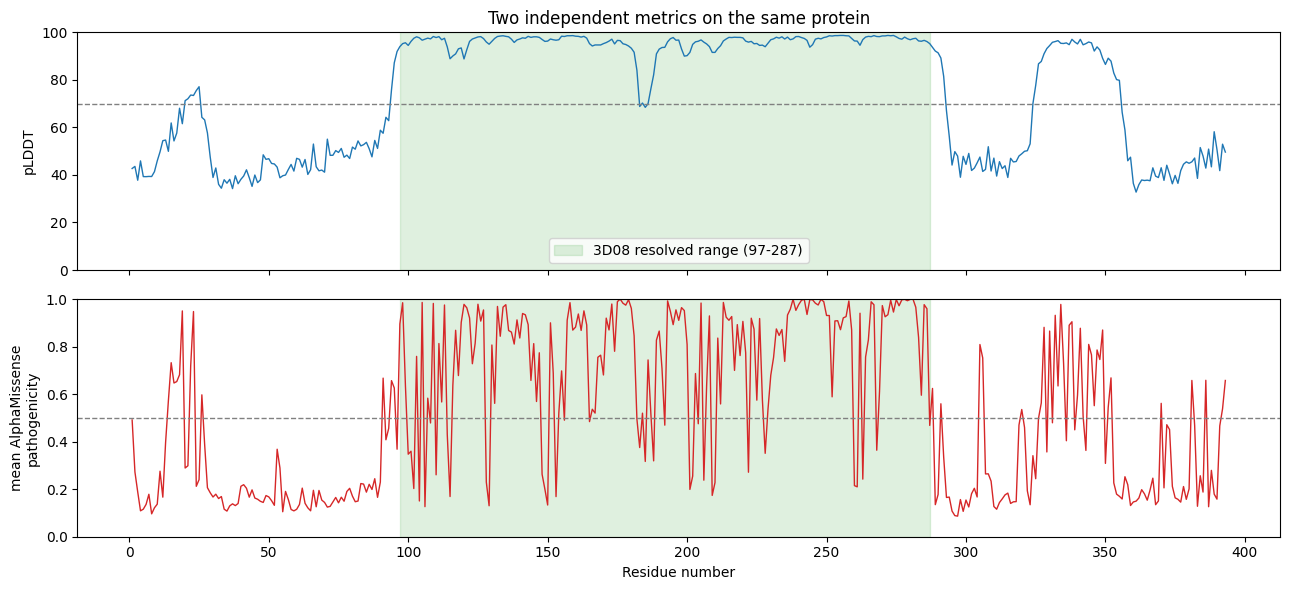


Mean pathogenicity, core 97-287: 0.756
Mean pathogenicity, the tails            : 0.310


In [9]:
import io

am_text = requests.get(entry["amAnnotationsUrl"]).text
am = pd.read_csv(io.StringIO(am_text))
am["pos"] = am["protein_variant"].str.extract(r"(\d+)").astype(int)
am["wt"] = am["protein_variant"].str[0]
am["mut"] = am["protein_variant"].str[-1]

print(f"AlphaMissense: {len(am):,} variants over positions "
      f"{am['pos'].min()}-{am['pos'].max()}")
print(f"  columns   : {list(am.columns[:3])}")
print(f"  classes   : {dict(am['am_class'].value_counts())}")
print("     LPath = likely pathogenic, LBen = likely benign, Amb = ambiguous")

# per-position mean pathogenicity, as a track we can line up against pLDDT
per_pos = am.groupby("pos")["am_pathogenicity"].mean()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
ax1.plot(confidence.index, confidence["pLDDT"], color="tab:blue", lw=1)
ax1.axhline(70, color="grey", ls="--", lw=1)
ax1.axvspan(CRYSTAL_START, CRYSTAL_END, color="tab:green", alpha=0.15,
            label=f"3D08 resolved range ({CRYSTAL_START}-{CRYSTAL_END})")
ax1.set_ylabel("pLDDT"); ax1.set_ylim(0, 100); ax1.legend(loc="lower center")
ax1.set_title("Two independent metrics on the same protein")

ax2.plot(per_pos.index, per_pos.values, color="tab:red", lw=1)
ax2.axhline(0.5, color="grey", ls="--", lw=1)
ax2.axvspan(CRYSTAL_START, CRYSTAL_END, color="tab:green", alpha=0.15)
ax2.set_xlabel("Residue number"); ax2.set_ylabel("mean AlphaMissense\npathogenicity")
ax2.set_ylim(0, 1)
plt.tight_layout(); plt.show()

core_mask = (per_pos.index >= CRYSTAL_START) & (per_pos.index <= CRYSTAL_END)
print(f"\nMean pathogenicity, core {CRYSTAL_START}-{CRYSTAL_END}: {per_pos[core_mask].mean():.3f}")
print(f"Mean pathogenicity, the tails            : {per_pos[~core_mask].mean():.3f}")

**The two tracks have the same shape** — the folded core is both confidently predicted and
intolerant to mutation; the tails are neither. But notice they say this for *unrelated*
reasons. pLDDT is high in the core because a deep MSA constrains the geometry.
AlphaMissense is high there because substitutions in a packed core disrupt function. Two
models, two training objectives, one conclusion: **that domain is where the protein does
its work.**

Agreement between independent methods is worth much more than a strong result from one.
This is the single most useful habit in the whole exercise.

### The variant heatmap, and the residue 3D08 is about

Now stop averaging and look at individual substitutions.

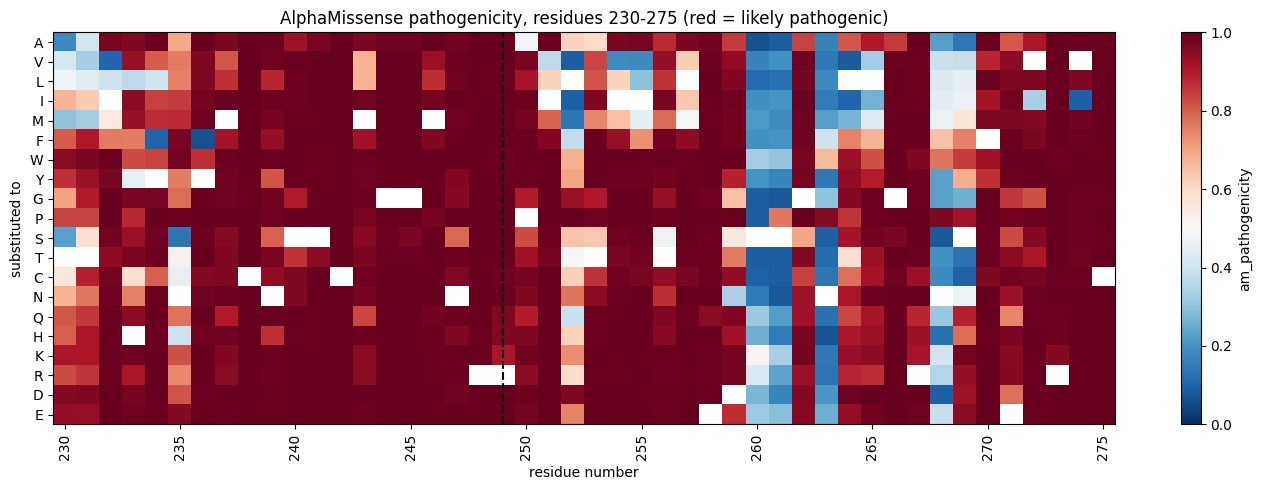

Every substitution at residue 249, worst first:
protein_variant  am_pathogenicity am_class
          R249D            0.9995    LPath
          R249S            0.9995    LPath
          R249T            0.9994    LPath
          R249F            0.9993    LPath
          R249A            0.9991    LPath
          R249M            0.9991    LPath
          R249P            0.9990    LPath
          R249N            0.9988    LPath


In [10]:
AA_ORDER = list("AVLIMFWYGPSTCNQHKRDE")

# Full 20 x N grid. Zoom on the region 3D08 resolved so the columns stay readable.
zoom_lo, zoom_hi = 230, 275
sub = am[(am["pos"] >= zoom_lo) & (am["pos"] <= zoom_hi)]
grid = sub.pivot_table(index="mut", columns="pos", values="am_pathogenicity").reindex(AA_ORDER)

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(grid.values, cmap="RdBu_r", vmin=0, vmax=1, aspect="auto")
ax.set_yticks(range(len(AA_ORDER))); ax.set_yticklabels(AA_ORDER)
step = 5
ax.set_xticks(range(0, grid.shape[1], step))
ax.set_xticklabels(grid.columns[::step], rotation=90)
ax.set_xlabel("residue number"); ax.set_ylabel("substituted to")
ax.set_title(f"AlphaMissense pathogenicity, residues {zoom_lo}-{zoom_hi} "
             "(red = likely pathogenic)")
fig.colorbar(im, ax=ax, label="am_pathogenicity")

# mark the column for residue 249 -- the mutation 3D08 actually carries
if 249 in grid.columns:
    ax.axvline(list(grid.columns).index(249), color="black", lw=1.5, ls="--")
plt.tight_layout(); plt.show()

print("Every substitution at residue 249, worst first:")
print(am[am["pos"] == 249].sort_values("am_pathogenicity", ascending=False)
      [["protein_variant", "am_pathogenicity", "am_class"]].head(8).to_string(index=False))

**Look at what that says.** 3D08's crystal carries **R249S** — a real hepatocellular
carcinoma hotspot — and AlphaMissense scores it **0.9995, likely pathogenic**. Not just
that substitution: essentially *every* substitution at position 249 is predicted damaging.
The column is solid red. Arginine 249 is not merely conserved; it is a position where the
protein tolerates nothing else.

Now cross-check it against something you compute yourself further down. This notebook
locates the residues coordinating 3D08's structural **Zn²⁺** purely from geometry —
Cys176, His179, Cys238, Cys242. AlphaMissense, which has never seen the crystal structure,
scores those four positions at **mean pathogenicity 0.998–1.000**: near-total intolerance.

**Two completely independent lines of evidence — a distance calculation on a crystal, and
a variant-effect model trained on population genetics — converge on the same four
residues.** That convergence is the finding, and neither method alone would have given it
to you.

---

## Making your own prediction: the AlphaFold Server

Everything above **looked up** a prediction that already existed. AlphaFold DB holds
precomputed models for UniProt sequences — which is wonderful when your protein is in
there, and useless when it is not: a mutant, a fragment, a complex, or a protein with a
ligand bound.

For those you run the prediction yourself, on the **[AlphaFold Server](https://alphafoldserver.com/)**.
It runs **AlphaFold 3**, it is free for academic use, and it needs no installation.

**What AF3 can do that AlphaFold DB cannot:**

| | AlphaFold DB | AlphaFold Server (AF3) |
|---|---|---|
| Input | a UniProt entry that already exists | any sequence you paste |
| Protein complexes | no | yes |
| DNA / RNA | no | yes |
| **Ligands, ions, modifications** | **no** | **yes** — by CCD code or SMILES |
| Cost | instant lookup | **20 jobs per day** |

That ligand support is the important one for this course: your own protein comes with a
ligand, and AF3 will predict the **complex** — protein and ligand together — which is a
fundamentally different thing from docking a ligand into a fixed receptor.

### Submitting 3D08's sequence

Let us reproduce, by hand, the prediction we have been reading from the database.

1. Go to <https://alphafoldserver.com/> and sign in with a Google account.
2. Choose **Protein** as the entity type.
3. Paste p53's core domain — residues 97-287, exactly 3D08's resolved range. The cell
   below prints it for you to copy.
4. *(Optional, and the interesting part.)* Add a second entity: **Ion → `ZN`**. 3D08's
   crystal contains a structural zinc, and AlphaFold DB's protein-only model does not.
   This is something you simply cannot ask AlphaFold DB.
5. Name the job, press **Continue and preview job**, then **Confirm and submit job**.
6. Wait — usually a few minutes — then **download** the result. You get a ZIP.

⚠️ **Mind the daily quota: 20 jobs.** Decide what you are asking before you submit, rather
than resubmitting variations. That constraint is realistic; compute is never free.

In [11]:
# The exact sequence to paste into the AlphaFold Server.
import textwrap
import urllib.request
import json as _json

with urllib.request.urlopen("https://rest.uniprot.org/uniprotkb/P04637.json", timeout=30) as r:
    p53 = _json.load(r)["sequence"]["value"]

core = p53[96:287]          # residues 97-287 == 3D08's resolved range
print(f"p53 core domain, residues 97-287 ({len(core)} aa) -- copy this:\n")
print("\n".join(textwrap.wrap(core, 60)))

p53 core domain, residues 97-287 (191 aa) -- copy this:

VPSQKTYQGSYGFRLGFLHSGTAKSVTCTYSPALNKMFCQLAKTCPVQLWVDSTPPPGTR
VRAMAIYKQSQHMTEVVRRCPHHERCSDSDGLAPPQHLIRVEGNLRVEYLDDRNTFRHSV
VVPYEPPEVGSDCTTIHYNYMCNSSCMGGMNRRPILTIITLEDSSGNLLGRNSFEVRVCA
CPGRDRRTEEE


### What comes back, and how to read it

Unzip the download. The files that matter:

| File | What it holds |
|---|---|
| `*_model.cif` | the predicted structure (mmCIF, not PDB) |
| `*_summary_confidences.json` | the headline numbers — `ptm`, `iptm`, `ranking_score`, `fraction_disordered`, `has_clash` |
| `*_confidences.json` | the full arrays — `atom_plddts`, `pae`, `contact_probs`, `token_chain_ids` |
| `ranking_scores.csv` | scores for every model produced, so you can see the spread |

Two things to notice before plotting anything.

**pLDDT is per *atom*, not per residue** (`atom_plddts`). AlphaFold DB gave us one value
per residue; AF3 works at atom resolution because it has to handle ligands and nucleic
acids, which do not have residues in the protein sense. To compare against what we plotted
earlier you must aggregate to residues.

**`ptm` and `iptm` are new.** `ptm` scores the whole predicted structure; **`iptm` scores
the *interfaces* between chains** — how confident the model is that two entities are
positioned correctly *relative to each other*. For a single protein `iptm` is meaningless.
For a protein with a ligand it is the number that matters most, and it is the one you will
use in ex04 when comparing co-folding against docking.

Upload your ZIP to this notebook, then:

In [12]:
# Read an AlphaFold Server result. Point these at your own unzipped download.
from pathlib import Path

SUMMARY = Path("fold_p53_core_summary_confidences.json")   # <-- your filename
FULL    = Path("fold_p53_core_confidences.json")           # <-- your filename

if not SUMMARY.exists():
    print("No AlphaFold Server output found in this directory.")
    print("Upload and unzip your job download, then set the two paths above.")
else:
    summary = _json.loads(SUMMARY.read_text())
    print("Summary confidences")
    for key in ("ranking_score", "ptm", "iptm", "fraction_disordered", "has_clash"):
        if key in summary:
            print(f"  {key:<20} {summary[key]}")

    full = _json.loads(FULL.read_text())
    atom_plddt = np.array(full["atom_plddts"])
    pae = np.array(full["pae"])
    print(f"\n  atom_plddts : {atom_plddt.shape[0]} atoms, mean {atom_plddt.mean():.1f}")
    print(f"  pae         : {pae.shape[0]} x {pae.shape[1]} tokens")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
    ax1.plot(atom_plddt, lw=0.6, color="tab:blue")
    ax1.axhline(70, color="grey", ls="--", lw=1)
    ax1.set_xlabel("atom index"); ax1.set_ylabel("pLDDT"); ax1.set_ylim(0, 100)
    ax1.set_title("Per-atom confidence")
    im = ax2.imshow(pae, cmap="Greens_r", vmin=0, vmax=pae.max())
    ax2.set_xlabel("aligned token"); ax2.set_ylabel("scored token")
    ax2.set_title("Predicted Aligned Error")
    fig.colorbar(im, ax=ax2, label="expected error (A)")
    plt.tight_layout(); plt.show()

No AlphaFold Server output found in this directory.
Upload and unzip your job download, then set the two paths above.


### Reading the two plots

**The pLDDT trace** should look like the AlphaFold DB curve you plotted earlier — high and
flat across the folded core. It will not be identical: AF3 is a different model from the
AF2 pipeline that produced the database entry, you gave it only the core domain rather
than the full 393-residue protein, and there is a random seed involved. **Compare the
shapes, not the decimal places.** If your core sits high and flat, the two models agree
about the thing that matters.

**The PAE matrix** is the more informative plot, and the one people skip. Read it as a
map, not a picture:

- **Dark blocks along the diagonal** = regions confidently placed *relative to themselves*
  — a domain.
- **Dark off-diagonal blocks** = two regions confidently placed *relative to each other* —
  they form a rigid unit.
- **Light off-diagonal regions** = the model has no idea how these two parts sit together,
  even if each is individually confident.

That last case is the one pLDDT alone will never tell you. Two domains can each score
pLDDT 95 while their relative orientation is a guess — high confidence in the parts,
none in the assembly.

**If you added the Zn ion**, look at the PAE rows and columns for that token: is the ion
confidently placed relative to the protein? Then check whether the residues nearest it are
the ones you found coordinating zinc in the crystal further down this notebook —
Cys176, His179, Cys238 and Cys242.

---

## 🔭 FRONTIER → Block C (Molecular Dynamics)

**⏭ Signpost:** You'll fully understand *why* this happens in Lectures 7–9, when we
cover molecular dynamics.

**The question:** AlphaFold gave p53's core domain (97-287) a very high, uniform
confidence score (~95-96 mean pLDDT) — but a pLDDT score is a **static, single-snapshot**
measure. Even within this "confident" domain, will every residue be equally *rigid* in an
actual molecular dynamics simulation?

**💡 Hint:** pLDDT measures how confident AlphaFold is about *where* a residue sits in one
predicted structure — it is not, by itself, a measurement of flexibility in solution. A
region can be confidently placed and still move.

**A worked answer, as a model of the reasoning:** no — high pLDDT and rigidity are
different claims about different things. Confidence says "I know where this sits";
flexibility says "this moves once you put it in water at 310 K." The regions to expect
movement in are the surface loops connecting the β-strands of the DNA-binding surface,
and the residues immediately flanking the crystal's own unresolved gaps (identified
further down) — a loop the crystal couldn't pin down is unlikely to sit still in
simulation either, even when AlphaFold is confident about its average position. The
Zn²⁺-coordinating site, by contrast, should be among the *most* rigid: a four-point
metal coordination physically clamps those residues together.

---

## Correlating the AlphaFold model with the 3D08 crystal: what actually changed?

Confidence metrics are AlphaFold's own self-assessment. The more direct check is to put
the AlphaFold model and the real crystal structure **side by side** and measure the
difference directly.

Two things worth knowing *before* looking at the numbers, so a deviation isn't
misread:

- AlphaFold DB's model is predicted from p53's **canonical (wild-type) UniProt
  sequence** (`entry["sequence"]`, already fetched above). 3D08's crystal carries the
  **R249S mutation** — so this comparison is partly "AlphaFold's WT prediction vs. a
  mutant crystal," not purely "prediction accuracy vs. experiment." A deviation right at
  residue 249 could reflect either.
- 3D08's crystal has a bound **structural Zn²⁺ ion**, coordinated by four residues
  (verified below). AlphaFold's model is **protein-only** — it does not predict ions,
  ligands, or cofactors at all. That's a categorical omission by design, not something an
  RMSD number will show you.

In [13]:
# Download both structures: AlphaFold's model (already have its URL in `entry`)
# and the 3D08 crystal (RCSB).
af_model_text = requests.get(entry["pdbUrl"]).text
crystal_text = requests.get("https://files.rcsb.org/download/3D08.pdb").text


def parse_ca_atoms(pdb_text, chain="A"):
    """Parse CA coordinates from PDB ATOM records, keyed by residue number.

    Uses fixed-width column parsing (the actual PDB format), not whitespace
    splitting -- whitespace splitting silently misparses some lines (e.g. when
    columns run together at 4-digit residue numbers).
    """
    coords = {}
    for line in pdb_text.splitlines():
        if not line.startswith("ATOM"):
            continue
        if line[12:16].strip() != "CA":
            continue
        if line[16] not in (" ", "A"):  # skip alternate conformations except the first
            continue
        if line[21] != chain:
            continue
        resnum = int(line[22:26])
        xyz = (float(line[30:38]), float(line[38:46]), float(line[46:54]))
        coords[resnum] = xyz
    return coords


af_ca = parse_ca_atoms(af_model_text)
crystal_ca = parse_ca_atoms(crystal_text)
print(f"AlphaFold model: {len(af_ca)} CA atoms, range {min(af_ca)}-{max(af_ca)}")
print(f"3D08 crystal: {len(crystal_ca)} CA atoms, range {min(crystal_ca)}-{max(crystal_ca)}")

# 3D08's crystal is NOT a clean, gap-free span -- match by residue number, not by
# list position, or a naive pairing would silently misalign everything past a gap.
common_residues = sorted(set(af_ca) & set(crystal_ca))
missing_from_crystal = [r for r in range(min(common_residues), max(common_residues) + 1)
                         if r not in crystal_ca]
print(f"Matched (by residue number) residues: {len(common_residues)}")
print(f"Residues with no crystal coordinates inside that range (unresolved loops): {missing_from_crystal}")


AlphaFold model: 393 CA atoms, range 1-393
3D08 crystal: 182 CA atoms, range 97-287
Matched (by residue number) residues: 182
Residues with no crystal coordinates inside that range (unresolved loops): [117, 118, 119, 120, 121, 183, 184, 185, 186]


In [14]:
import numpy as np

# Superimpose the AlphaFold model onto the crystal using the matched CA atoms
# (Kabsch algorithm) -- this is the actual math behind "structural alignment."
P = np.array([af_ca[r] for r in common_residues])       # AlphaFold model (mobile)
Q = np.array([crystal_ca[r] for r in common_residues])  # crystal (reference)

P_centroid, Q_centroid = P.mean(axis=0), Q.mean(axis=0)
Pc, Qc = P - P_centroid, Q - Q_centroid

H = Pc.T @ Qc
U, S, Vt = np.linalg.svd(H)
d = np.sign(np.linalg.det(Vt.T @ U.T))
correction = np.diag([1, 1, d])  # guards against an improper rotation (reflection)
R = Vt.T @ correction @ U.T

P_aligned = (R @ Pc.T).T + Q_centroid
per_residue_deviation = np.linalg.norm(P_aligned - Q, axis=1)
overall_rmsd = np.sqrt((per_residue_deviation ** 2).mean())

print(f"Overall CA RMSD over {len(common_residues)} matched residues: {overall_rmsd:.2f} Å")

deviation_by_residue = dict(zip(common_residues, per_residue_deviation))
worst = sorted(deviation_by_residue.items(), key=lambda kv: -kv[1])[:10]
print("\nHighest-deviation residues:")
for resnum, dev in worst:
    print(f"  residue {resnum}: {dev:.2f} Å")

print(f"\nDeviation right at the R249S hotspot: {deviation_by_residue.get(249, float('nan')):.2f} Å")


Overall CA RMSD over 182 matched residues: 0.76 Å

Highest-deviation residues:
  residue 116: 5.69 Å
  residue 115: 4.46 Å
  residue 225: 2.48 Å
  residue 226: 2.41 Å
  residue 114: 1.81 Å
  residue 201: 1.40 Å
  residue 227: 1.37 Å
  residue 182: 1.22 Å
  residue 224: 1.21 Å
  residue 181: 1.16 Å

Deviation right at the R249S hotspot: 0.12 Å


**What this shows, in a live-verified run:** an overall CA RMSD around 0.7-0.8 Å across
the whole matched domain — AlphaFold's fold-level prediction of the core domain is very
close to the crystal, wild-type-vs-mutant notwithstanding. Deviation right at residue
249 itself is small, similar in size to the average — the R249S mutation changes a side
chain, not the backbone path there. The **highest**-deviation residues instead cluster
immediately **next to the crystal's own unresolved loops** (missing residues printed
above) — which makes sense: a static AlphaFold prediction is compared against one
specific crystal snapshot, and the regions right at the edge of a genuinely
flexible/disordered loop are exactly where a single crystal conformation and a single
predicted conformation are least likely to agree, independent of whether the prediction
is "wrong." ⚠️ Exact numbers depend on the live AlphaFold DB model version — re-verify if
this section is ever re-run and the numbers look different.

In [15]:
# Locate the residues that actually coordinate the structural Zn (within 2.6 Å,
# a typical direct-coordination distance) -- confirms the claim above with real
# geometry, and gives us something concrete to zoom in on.
zn_position = None
for line in crystal_text.splitlines():
    if line.startswith("HETATM") and line[17:20].strip() == "ZN":
        zn_position = np.array([float(line[30:38]), float(line[38:46]), float(line[46:54])])
        break

zn_coordinating_residues = []
for line in crystal_text.splitlines():
    if not line.startswith("ATOM"):
        continue
    resnum = int(line[22:26])
    xyz = np.array([float(line[30:38]), float(line[38:46]), float(line[46:54])])
    if np.linalg.norm(xyz - zn_position) < 2.6:
        zn_coordinating_residues.append(resnum)

zn_coordinating_residues = sorted(set(zn_coordinating_residues))
print(f"Residues directly coordinating the structural Zn²⁺: {zn_coordinating_residues}")
print("(A classic Cys/His zinc-finger-like site -- present in the crystal, absent from the AlphaFold model.)")


Residues directly coordinating the structural Zn²⁺: [176, 179, 238, 242]
(A classic Cys/His zinc-finger-like site -- present in the crystal, absent from the AlphaFold model.)


In [16]:
# Apply the same rotation+translation to the FULL AlphaFold model (not just the
# matched CA atoms), so the whole structure moves together, then overlay both
# structures in one py3Dmol view.
def apply_transform(pdb_text, R, translation_from, translation_to):
    new_lines = []
    for line in pdb_text.splitlines():
        if line.startswith(("ATOM", "HETATM")):
            xyz = np.array([float(line[30:38]), float(line[38:46]), float(line[46:54])])
            new_xyz = (R @ (xyz - translation_from)) + translation_to
            line = f"{line[:30]}{new_xyz[0]:8.3f}{new_xyz[1]:8.3f}{new_xyz[2]:8.3f}{line[54:]}"
        new_lines.append(line)
    return "\n".join(new_lines)


af_model_aligned_text = apply_transform(af_model_text, R, P_centroid, Q_centroid)

view = py3Dmol.view(width=900, height=550)
view.addModel(crystal_text, "pdb")
view.setStyle({"model": 0}, {"cartoon": {"color": "skyblue"}})
view.addModel(af_model_aligned_text, "pdb")
view.setStyle({"model": 1}, {"cartoon": {"color": "orange"}})

# Zoom on the R249S hotspot and the Zn-coordinating residues together
highlight_resi = [249] + zn_coordinating_residues
view.addStyle({"model": 0, "resi": highlight_resi}, {"stick": {"color": "skyblue"}})
view.addStyle({"model": 1, "resi": highlight_resi}, {"stick": {"color": "orange"}})
view.addStyle({"model": 0, "resn": "ZN"}, {"sphere": {"color": "grey", "radius": 0.6}})

view.zoomTo({"model": 0, "resi": highlight_resi})
view.show()
print("Blue = 3D08 crystal (R249S mutant, with bound Zn). Orange = AlphaFold's WT model (no Zn, no ligand).")


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Blue = 3D08 crystal (R249S mutant, with bound Zn). Orange = AlphaFold's WT model (no Zn, no ligand).


---

# End of the guide

One real AlphaFold prediction, taken apart: where the data comes from, what pLDDT and PAE
each answer, what AlphaMissense adds that neither can, how the model compares against the
crystal — and what it leaves out.

**Now open `ex02_workbook.ipynb`.**